In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [4]:
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix"
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)

[PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_2'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_klow'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_khigh'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_ksuper_high'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/base_red_ksuper_low'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/red_ksuper_low_1E8'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/red_ksuper_low_2'),
 PosixPath('/Users/pp/data/Simulations/A08_SimPHony/swiss/medlyn_fix/.DS_Store')]

In [6]:
sorted(Path(root_output_directory).iterdir(), key=os.path.getmtime)
scenario_name = "red_ksuper_low_2"
input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')
df = pd.read_csv(os.path.join(post_path, 'parameters_best_0.csv'))
range_real = [0, 1, 3, 4, 6, 7, 9, 10, 11, 12, 13]
range_alive = [1, 4, 9, 10, 11, 12, 13]
range_dead = [0, 3, 6, 7]

In [7]:
df_dead_list = []
for id in range_dead:
    df = pd.read_csv(os.path.join(post_path, f'parameters_best_{id}.csv')).sort_values(by=[f't{id}'])
    df.reset_index(inplace=True)
    df_dead_list.append(df)
df_alive = pd.read_csv(os.path.join(post_path, f'parameters_best_mean_alive.csv')).sort_values(by=['alive_mean'])
df_alive.reset_index(inplace=True)
variables = ['psi_leaf_50_close', 'd_50_close', 'stem_hydraulic_capacitance', 'k_xylem_sat', 'huber_value',
             'leaf_hydraulic_capacitance', 'psi50_xylem', 'g0', 'g1', 'k_soil_sat0', 'psi_soil_sat0',
             'jackson_root_beta', 'pore_0', 'anet_max', 'root_area_index', 'wcont_sigma_deviation', 'g_bark']

In [8]:
dfd = df_dead_list[0][variables][0:20000]
dfd['alive'] = 0
dfa = df_alive[variables][0:20000]
dfa['alive'] = 1
dfcs = pd.concat([dfd, dfa], axis=0)
dfc = dfcs.drop(['alive'], axis=1)
dfc = (dfc - dfc.mean()) / dfc.std()

In [9]:
dfc

,psi_leaf_50_close,d_50_close,stem_hydraulic_capacitance,k_xylem_sat,huber_value,leaf_hydraulic_capacitance,psi50_xylem,g0,g1,k_soil_sat0,psi_soil_sat0,jackson_root_beta,pore_0,anet_max,root_area_index,wcont_sigma_deviation,g_bark
0,1.308405,0.413686,-0.985958,1.210626,0.154757,-1.012915,1.527626,0.583604,-0.124778,-0.826411,1.393613,-0.732864,-0.761529,-0.814297,-1.342617,-0.359675,0.938979
1,1.171978,-1.708115,-0.880829,0.619627,0.953224,0.404754,-0.824082,0.582810,-1.146996,-1.408665,-1.608766,-0.642952,-0.169992,-0.798932,0.253867,-2.047945,1.498113
2,1.040647,1.038929,-1.220674,0.770686,1.003818,1.019042,-0.411178,-0.290974,-0.861043,-1.592190,1.212146,-0.274127,-1.303172,-0.791464,-0.380157,0.163303,0.744003
3,1.110566,0.173923,-0.870924,0.794074,0.917578,-0.655662,-0.820784,1.119139,-1.346595,-1.717154,-1.474186,-0.945667,-1.761774,-0.804731,-0.375822,0.849102,0.788096
4,0.685805,0.864573,-0.900143,0.673914,0.619793,1.930568,1.720610,1.744248,-1.037794,-0.772178,-0.769114,-0.015193,-1.242106,-0.820222,-0.132309,-0.077789,1.360858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,-0.584260,-0.247016,1.451931,-1.879941,1.064351,1.952306,0.607789,-0.935495,-0.415107,0.534455,0.111243,-1.020441,1.050323,1.662509,-1.264491,-0.309483,-1.198030
19996,-1.864625,1.448954,-0.873901,-1.928865,0.568657,0.420616,0.849506,-1.382708,-0.150253,0.348386,-0.328168,2.042734,1.084615,2.530316,1.168930,0.990013,-1.528746
19997,0.224835,1.454601,1.140761,0.178488,-0.891055,-0.959615,-1.680322,0.378251,-1.004441,-0.169097,0.259750,0.755172,1.020693,0.051697,0.060566,1.071759,-0.987597
19998,-0.975399,0.943745,1.159411,-1.139507,0.398065,-0.936357,0.572146,0.885444,0.013460,0.823389,-1.710226,-0.588346,1.056604,0.930709,-0.947464,0.467091,-0.500860


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(dfc, dfcs['alive'], test_size=0.2, random_state=42)

In [10]:
# Create and train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Get the coefficients
coefficients = model.coef_[0]
feature_names = dfc.columns

# Print feature importance
for feature, coefficient in zip(feature_names, coefficients):
    print(f"{feature}: {coefficient:.3f}")    

sum_coeff = 0.0
for feature, coefficient in zip(feature_names, coefficients):
    sum_coeff += abs(coefficient)
   


psi_leaf_50_close: -0.216
d_50_close: 0.061
stem_hydraulic_capacitance: 1.824
k_xylem_sat: -0.514
huber_value: 0.042
leaf_hydraulic_capacitance: -0.078
psi50_xylem: 0.020
g0: -0.289
g1: 0.251
k_soil_sat0: 2.364
psi_soil_sat0: 0.126
jackson_root_beta: 0.075
pore_0: 3.815
anet_max: 0.818
root_area_index: 2.107
wcont_sigma_deviation: 3.551
g_bark: -1.359


In [11]:
soil_vars = ['pore_0', 'wcont_sigma_deviation', 'k_soil_sat0', 'psi_soil_sat0']
plant_vars = list(set(variables)-set(soil_vars) )

In [12]:
dict_all = {}
# Print feature importance
for feature, coefficient in zip(feature_names, coefficients):
    dict_all[feature] = coefficient / sum_coeff

In [13]:
from sklearn.ensemble import RandomForestRegressor

In [16]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    random_state=2909,)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=3, random_state=2909)

In [17]:
rf.score(X_train, y_train)

0.9588485561537516

<Axes: >

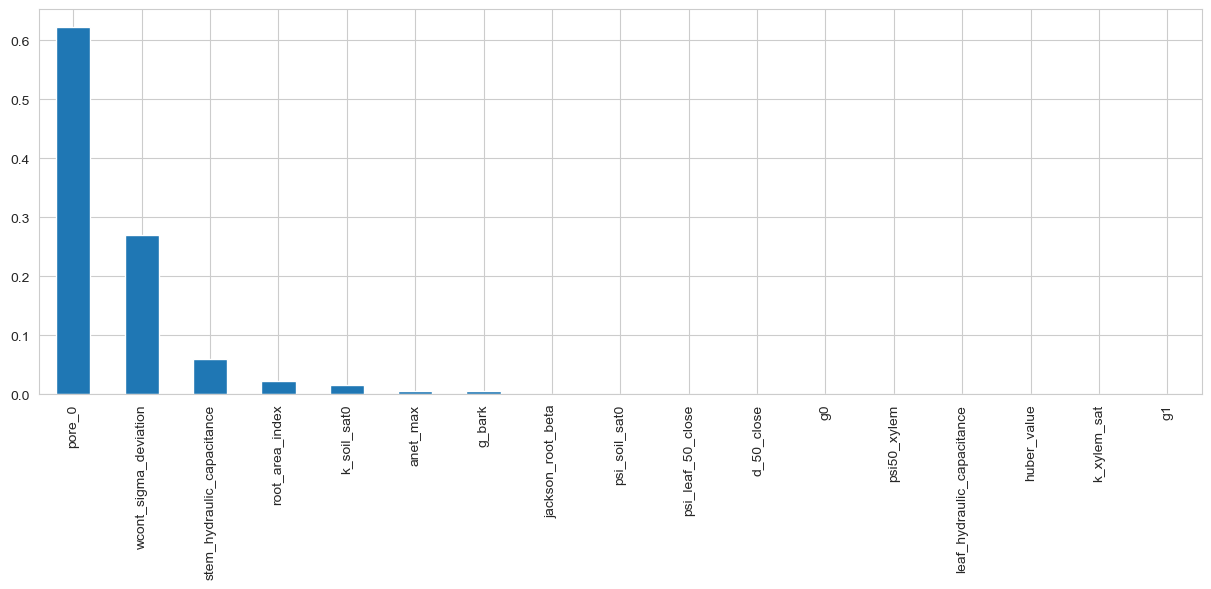

In [18]:
pd.Series(
    rf.feature_importances_,
    index=rf.feature_names_in_,
).sort_values(
    ascending=False).plot.bar(figsize=(15, 5))

In [19]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(
    rf, 
    X_test, # we use the test set
    y_test,
    scoring= "r2", # we can use any metric
    n_repeats=100, 
    random_state=0,
)

In [20]:
importance = pd.DataFrame(
    {"importance_mean": perm["importances_mean"],
     "importance_std": perm["importances_std"]},
    index=rf.feature_names_in_)

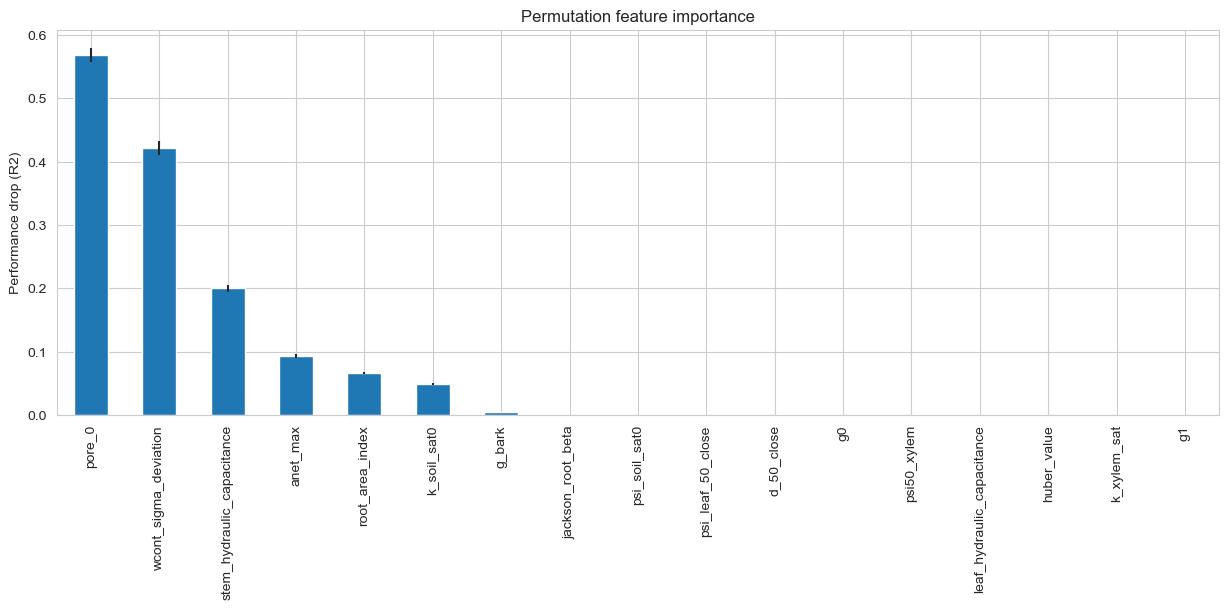

In [21]:
importance["importance_mean"].sort_values(
    ascending=False
).plot(figsize=(15, 5), kind="bar", yerr=importance["importance_std"])
plt.title("Permutation feature importance")
plt.ylabel("Performance drop (R2)")
plt.show()